# PV Installed Capacity Estimation

In this notebook, we look at the impact of installed PV on aggregated net load. We will look at relevant statistical features for estimation of aggregated installed PV capacity, and review some methods for this estimation

Import Backend functions

In [1]:
from backend import *   

Load pre-generated synthetic substation data

In [2]:
subdata, sizes, dfs, Is = loadDataFluvius()

Visualise net load and GHI for a specific substations and day, and the net load for the whole dataset (2022)

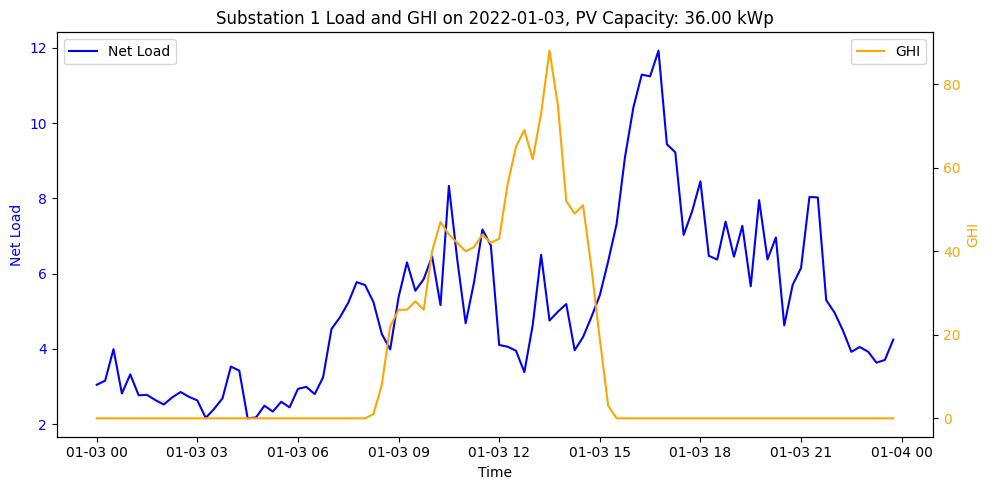

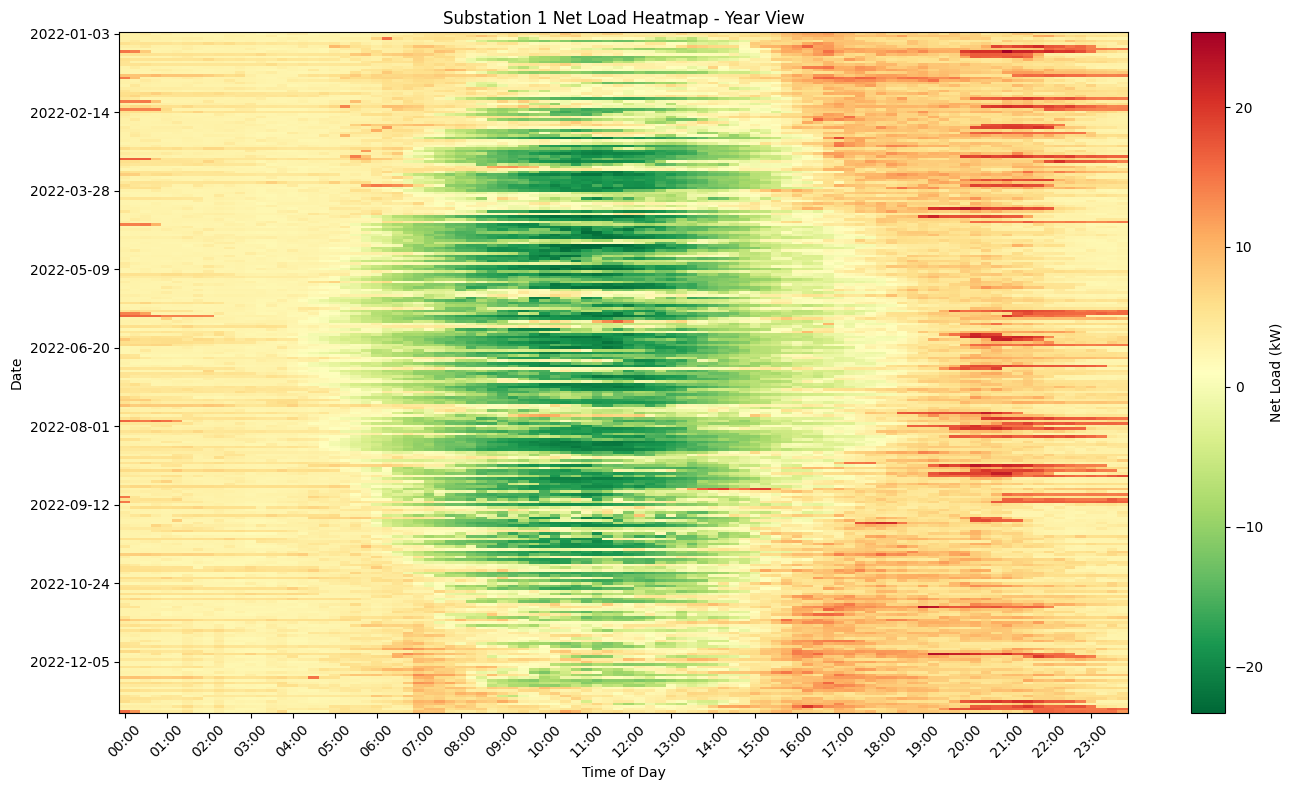

In [3]:
visualizeSubstationLoad(dfs, index=1, date='2022-01-03')    # index [0-99] and date in 'YYYY-MM-DD' format (only for 2022, no weekends)

Visualize net load and GHI for a specific substations and day, and the net load for the whole dataset (2022), using relative solar time and relative solar time bins as index

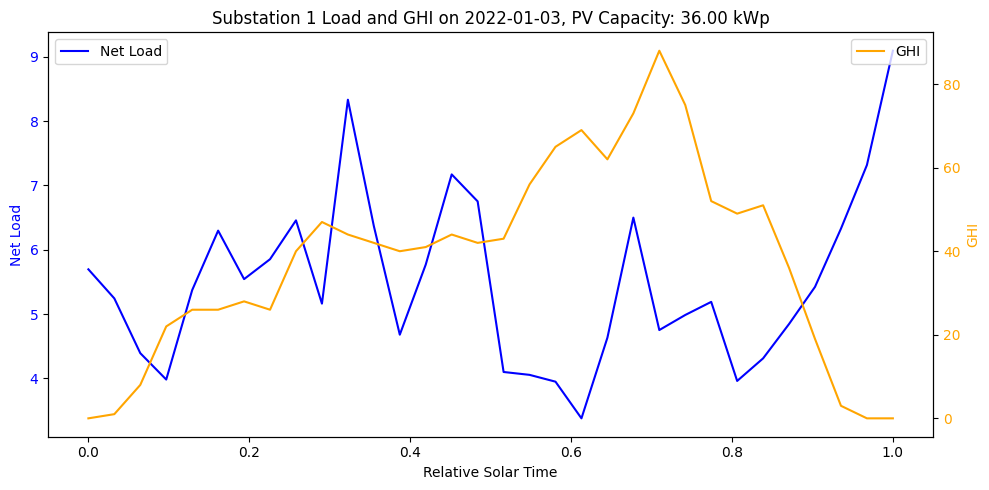

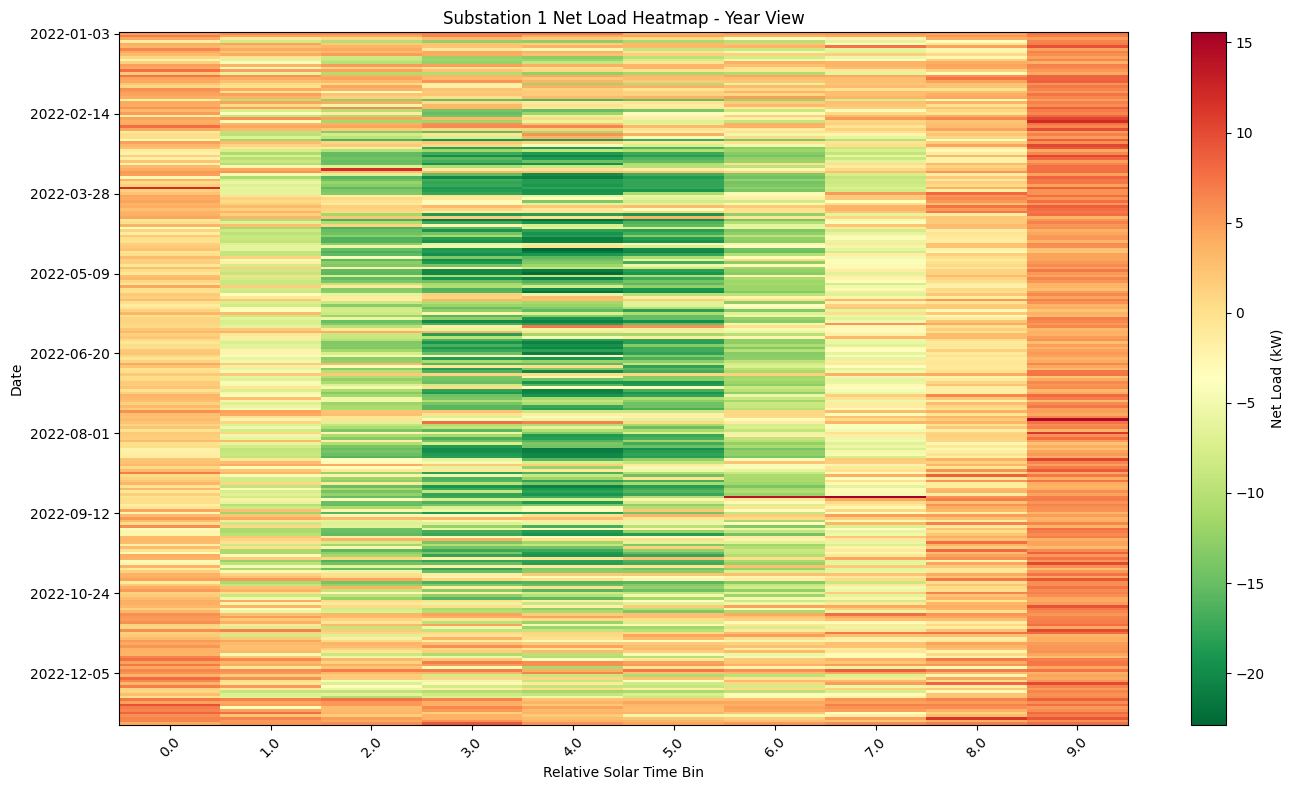

In [4]:
visualizeSubstationLoadSolarTime(dfs, index=1, date='2022-01-03')    # index [0-99] and date in 'YYYY-MM-DD' format (only for 2022, no weekends)
                                                                     # change 'res' argument (default=10) to change the number of tau bins

Split data into training and test features, labels, load and irradiance profiles, and feature scaler model. 

In [5]:
splitData_dict = splitData(subdata, dfs, Is, test_size=1)
splitData_dict.keys()

dict_keys(['dfs_Train', 'dfs_Test', 'Is_Train', 'Is_Test', 'XIrrTrain_MC', 'XIrrTrain_MC_normalized', 'yIrrTrain_MC', 'XIrrTest_MC', 'XIrrTest_MC_normalized', 'yIrrTest_MC', 'scaler'])

In [6]:
X_Train = splitData_dict['XIrrTrain_MC']                        #   Train features
X_Test_normalized = splitData_dict['XIrrTest_MC_normalized']    #   Normalized test features
y_Train = splitData_dict['yIrrTrain_MC']                        #   Train target variable (PVkWp)
y_Test = splitData_dict['yIrrTest_MC']                          #   Test target variable (PVkWp)
dfs_Test = splitData_dict['dfs_Test']                           #   Test timeseries for each substation (Net load, GHI, DNI, DHI)
Is_Test = splitData_dict['Is_Test']                             #   Test Plane of Array (POA) irradiance
scaler = splitData_dict['scaler']                               #   Scaler for normalizing test features

Look at the relationship between each feature and the target value (installed PV capacity in kWp)

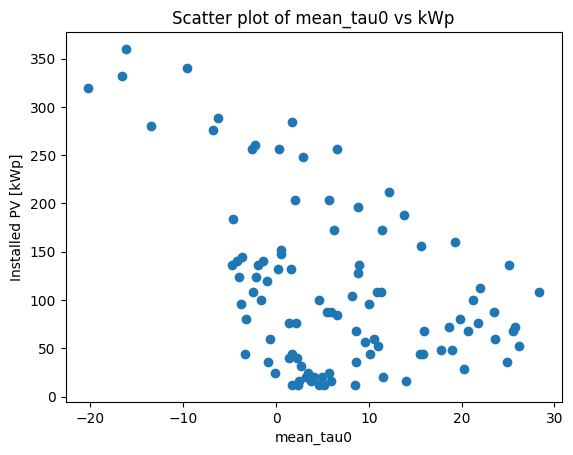

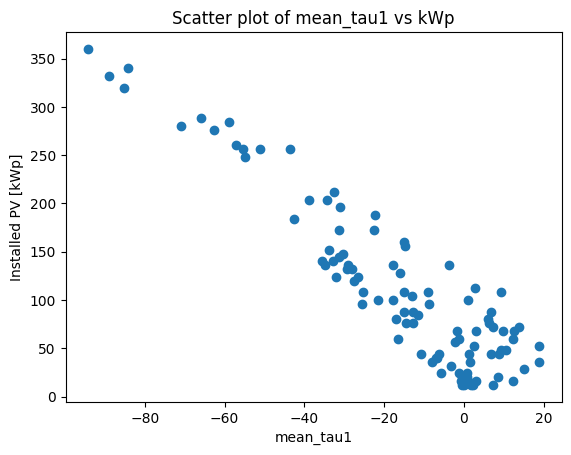

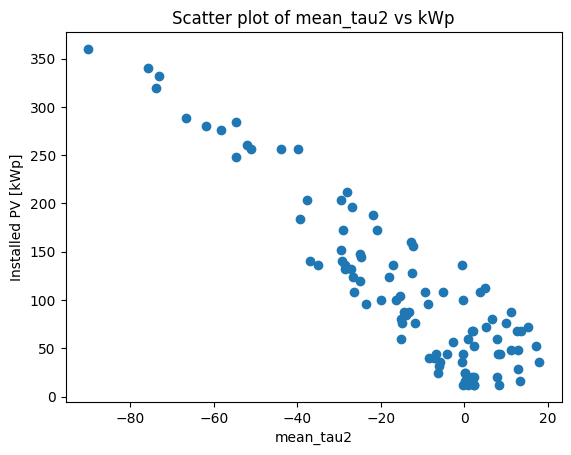

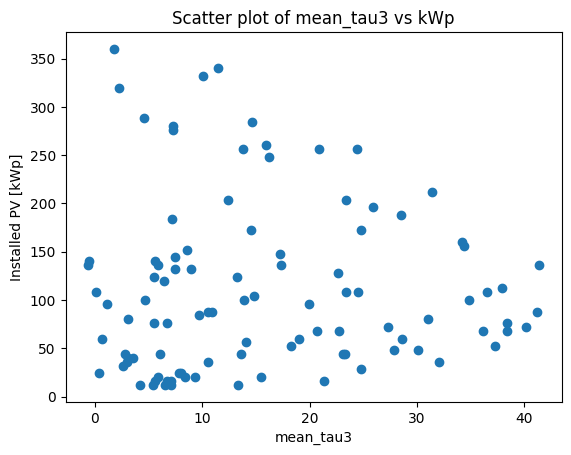

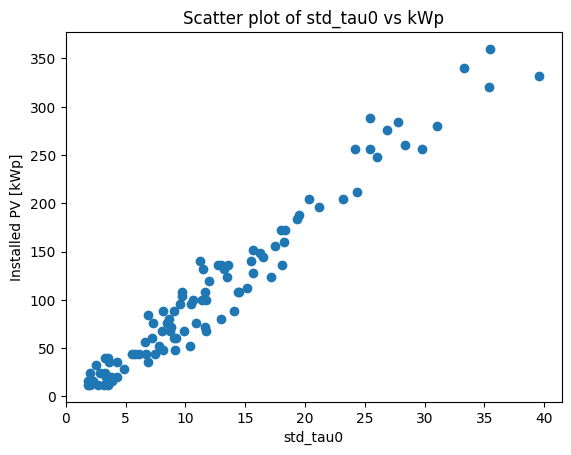

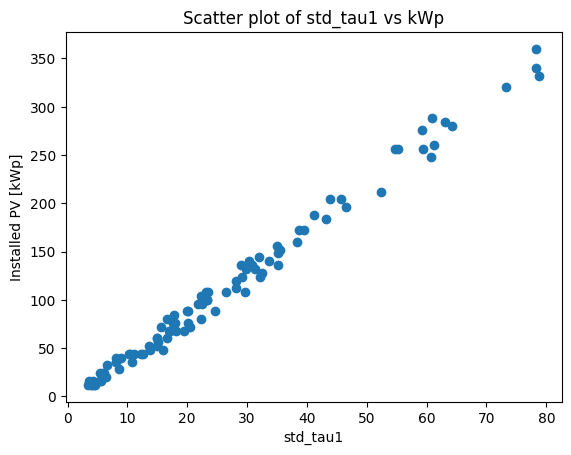

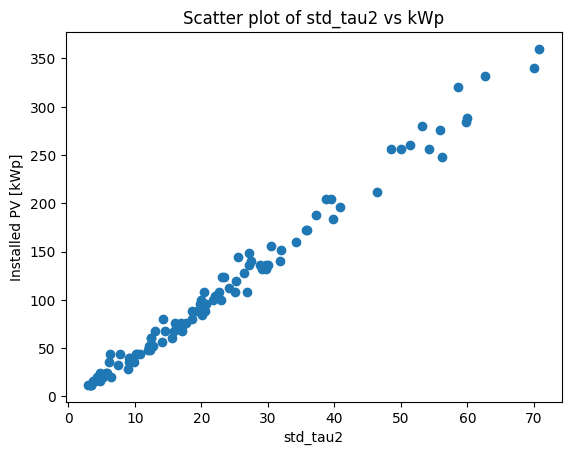

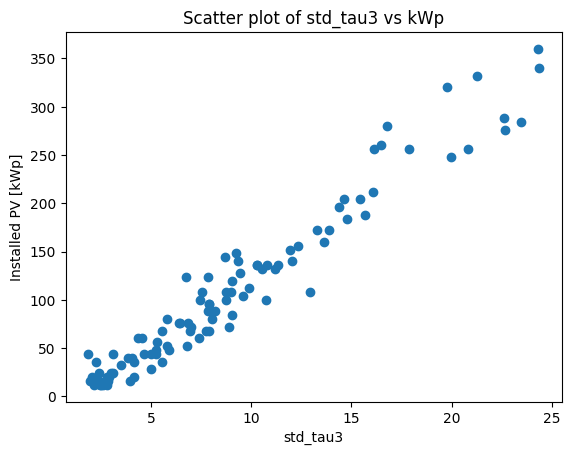

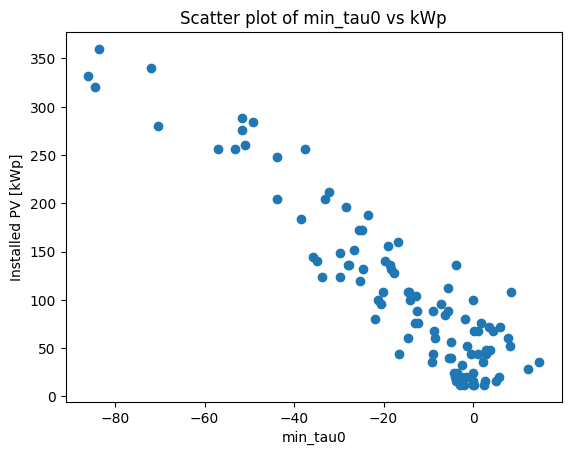

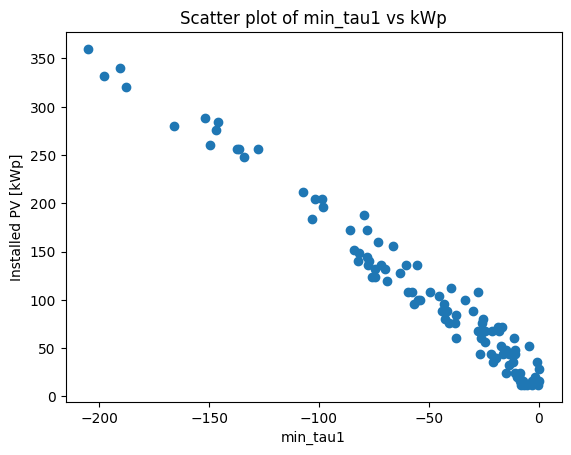

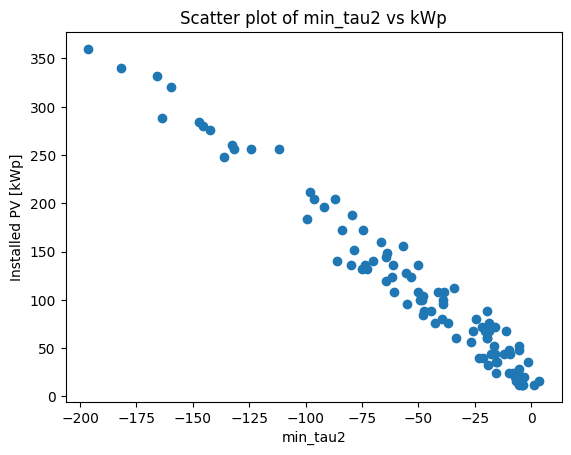

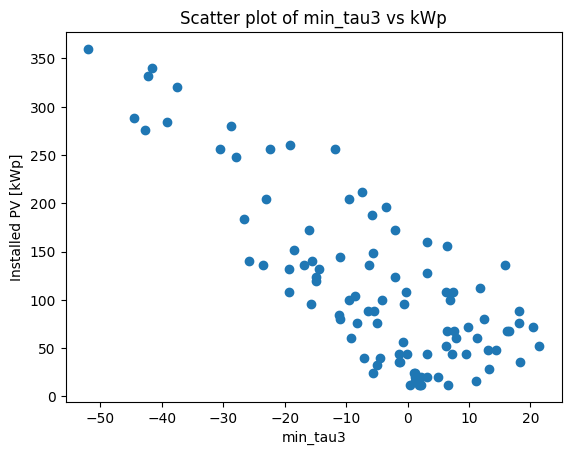

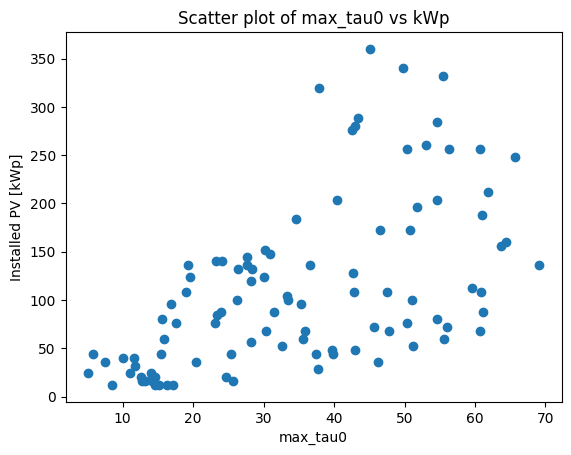

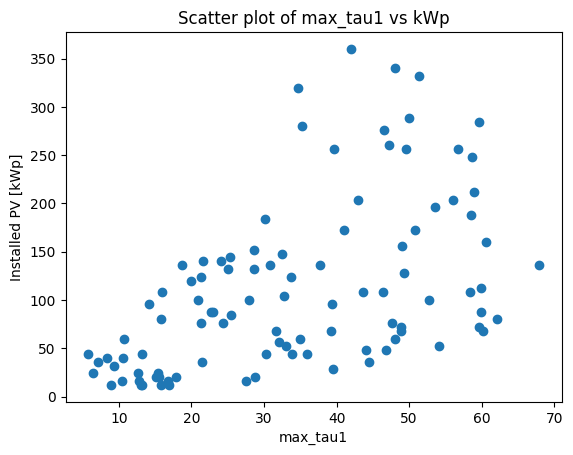

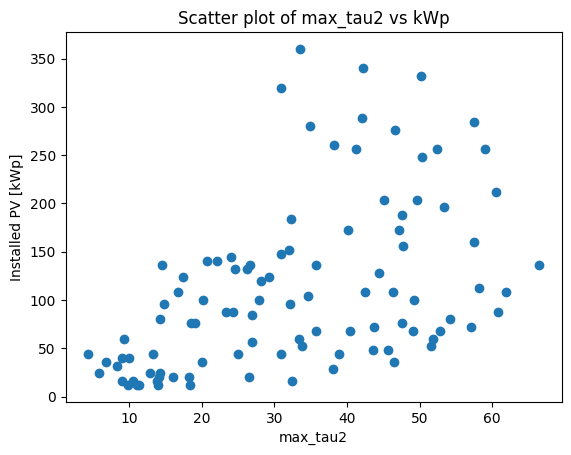

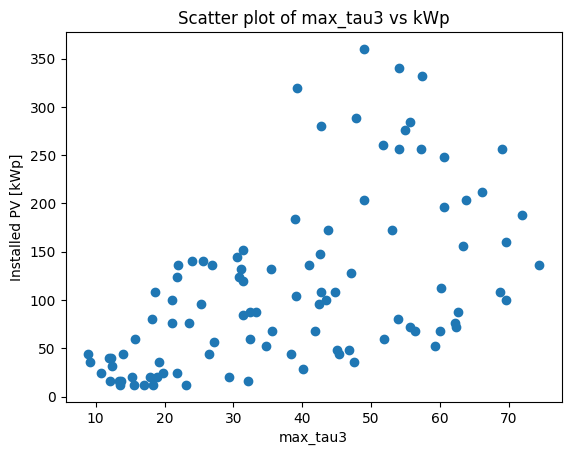

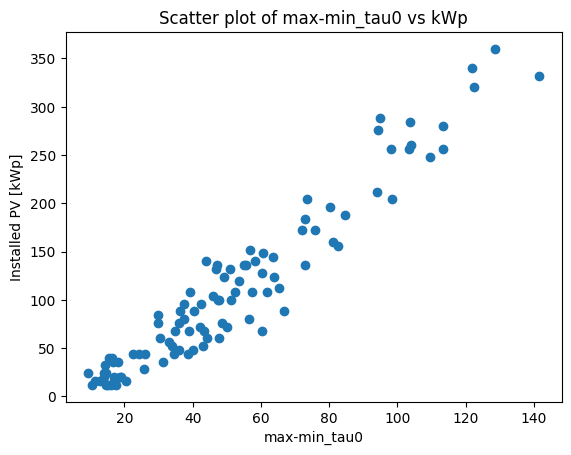

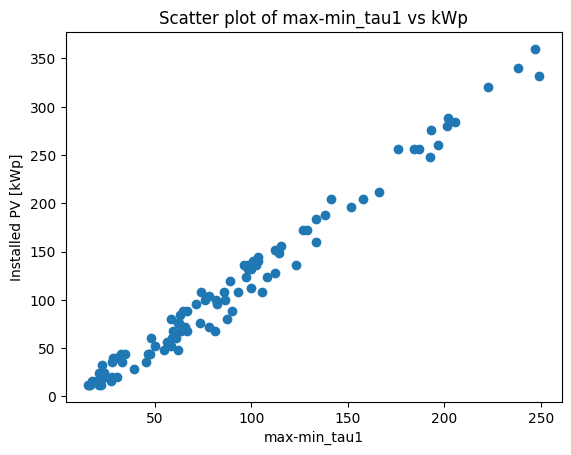

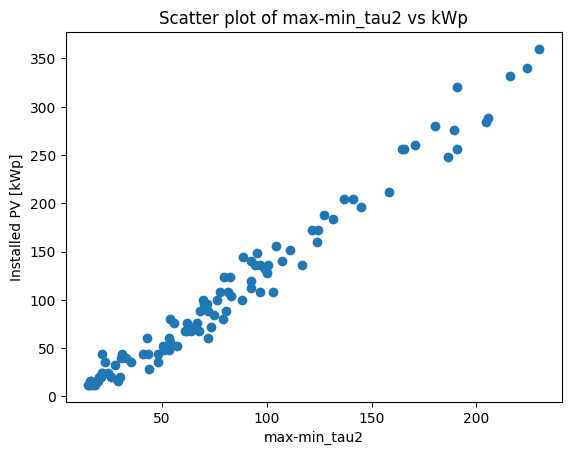

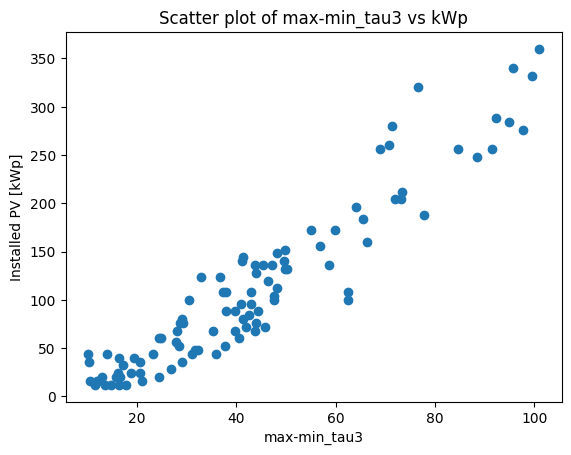

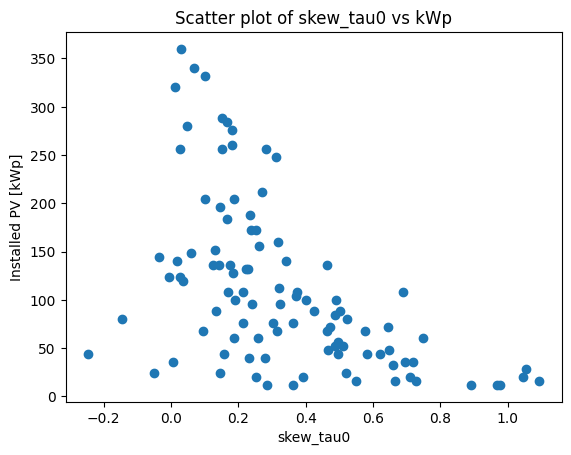

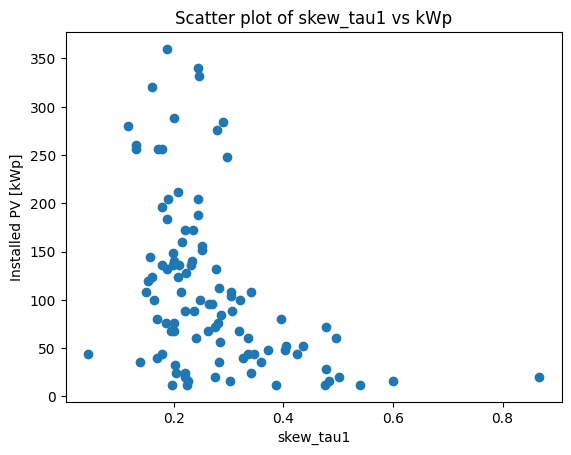

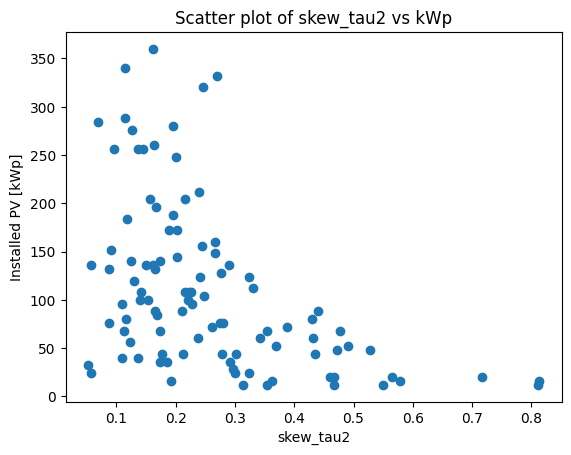

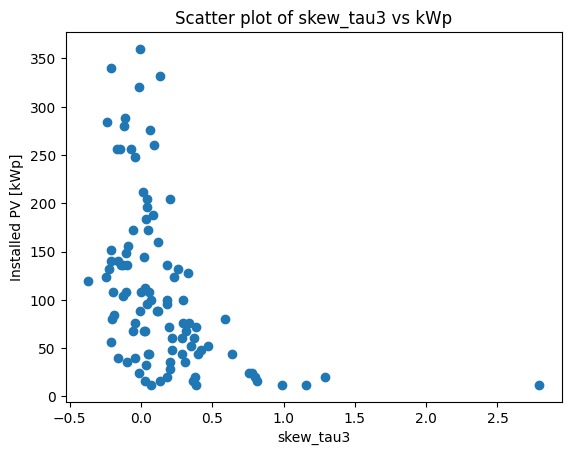

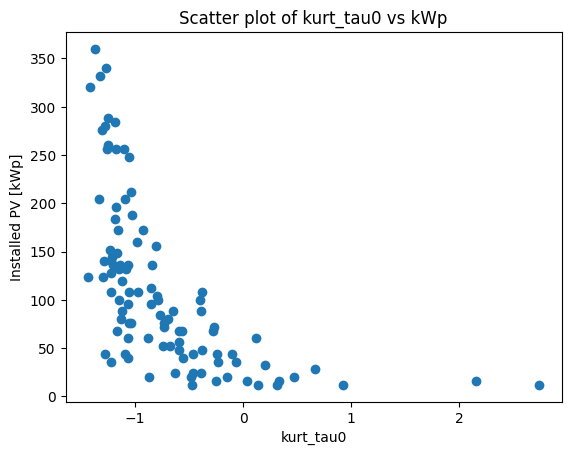

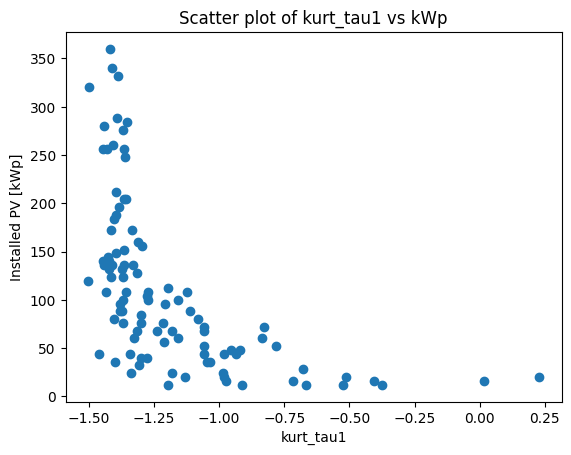

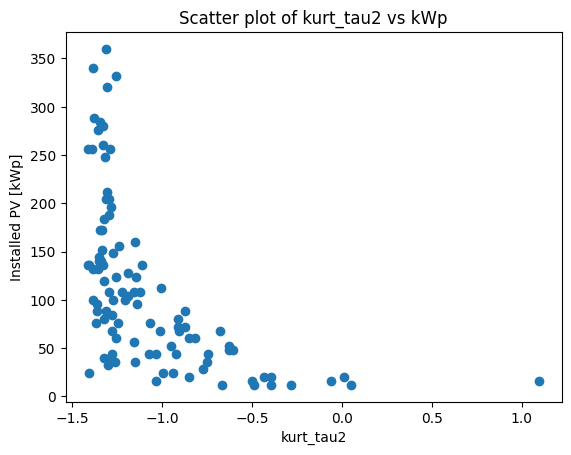

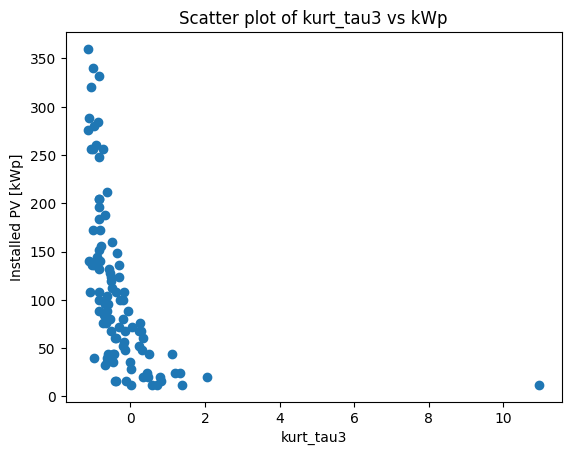

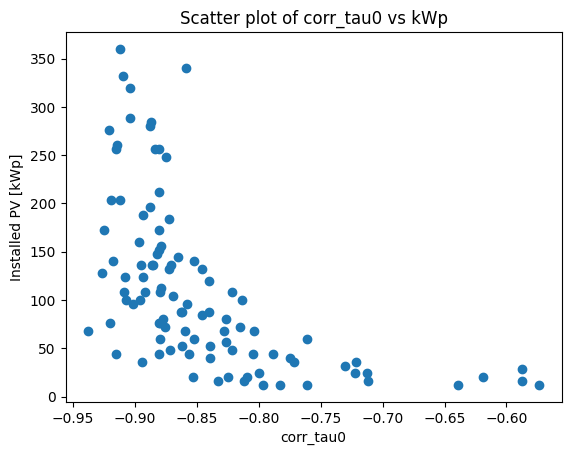

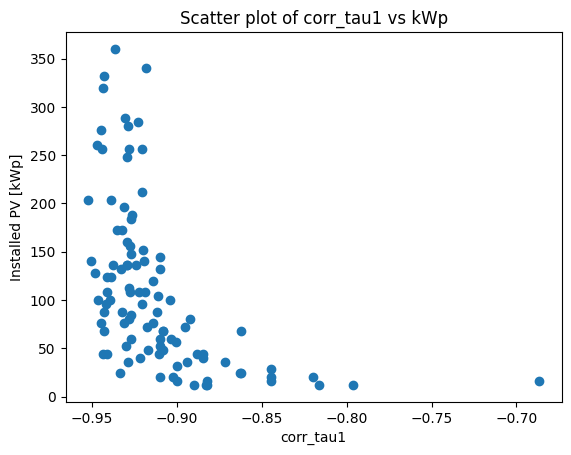

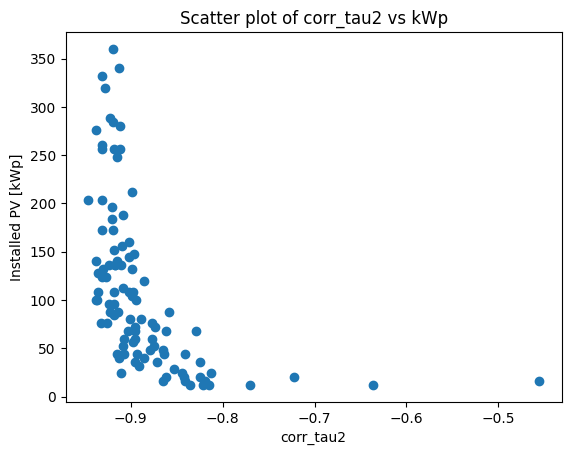

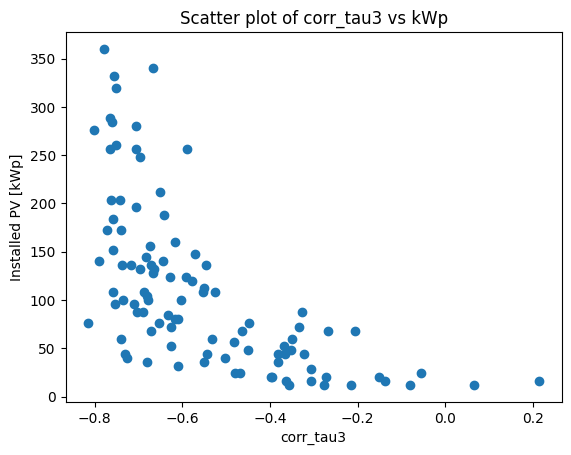

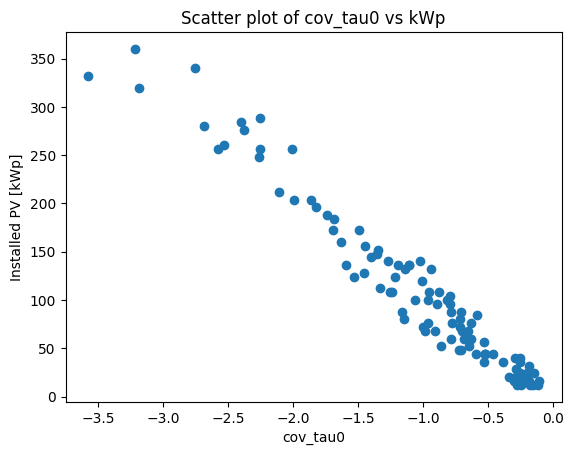

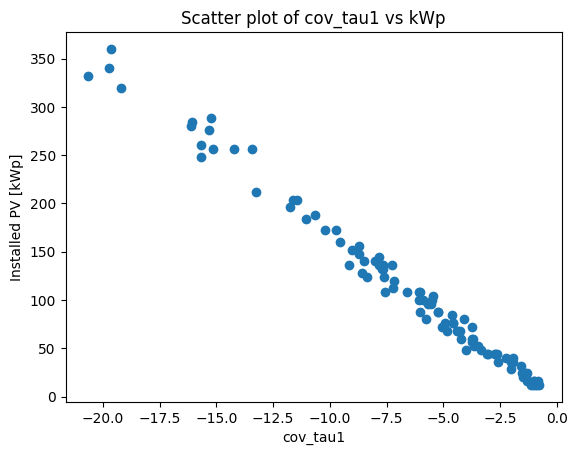

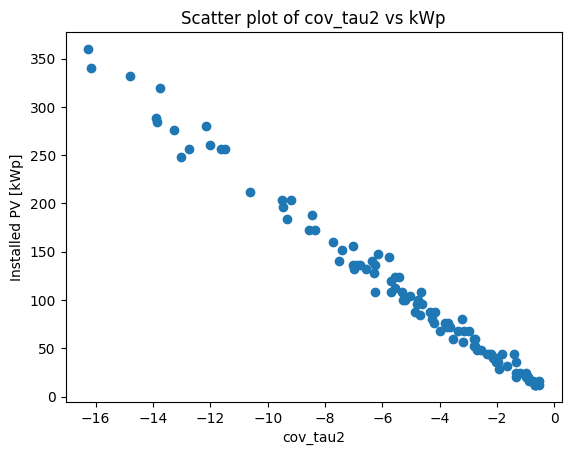

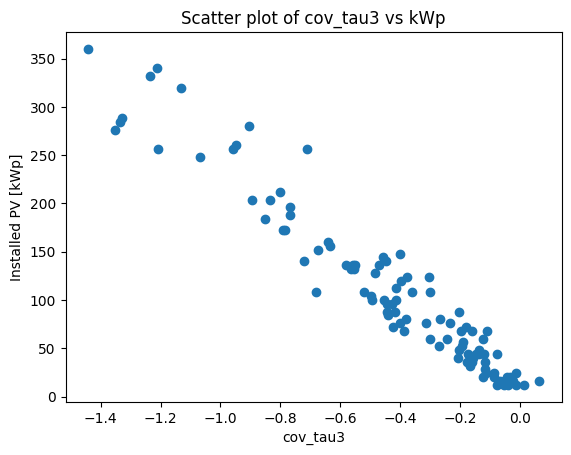

In [7]:
viewFeatures(X_Train, y_Train)

Observe the correlation table between each feature and the label (again, installed PV capacity)

In [8]:
viewFeatureCorrelations(X_Train, y_Train)

,mean_tau0,mean_tau1,mean_tau2,mean_tau3,std_tau0,std_tau1,std_tau2,std_tau3,min_tau0,min_tau1,min_tau2,min_tau3,max_tau0,max_tau1,max_tau2,max_tau3,max-min_tau0,max-min_tau1,max-min_tau2,max-min_tau3,skew_tau0,skew_tau1,skew_tau2,skew_tau3,kurt_tau0,kurt_tau1,kurt_tau2,kurt_tau3,corr_tau0,corr_tau1,corr_tau2,corr_tau3,cov_tau0,cov_tau1,cov_tau2,cov_tau3,maxPV
mean_tau0,1.000,0.768,0.765,0.856,-0.373,-0.430,-0.410,-0.317,0.738,0.598,0.578,0.837,0.436,0.485,0.517,0.457,-0.278,-0.374,-0.343,-0.213,0.534,0.384,0.326,0.109,0.362,0.384,0.343,0.134,0.246,0.235,0.233,0.395,0.388,0.436,0.420,0.420,-0.463
mean_tau1,0.768,1.000,0.994,0.387,-0.862,-0.904,-0.896,-0.838,0.983,0.971,0.962,0.933,-0.218,-0.158,-0.120,-0.194,-0.809,-0.876,-0.861,-0.774,0.606,0.465,0.486,0.363,0.576,0.576,0.550,0.355,0.505,0.455,0.446,0.629,0.867,0.906,0.900,0.877,-0.920
mean_tau2,0.765,0.994,1.000,0.415,-0.836,-0.889,-0.895,-0.845,0.961,0.958,0.965,0.956,-0.201,-0.142,-0.100,-0.179,-0.784,-0.861,-0.858,-0.777,0.576,0.445,0.518,0.373,0.560,0.571,0.567,0.366,0.489,0.456,0.461,0.654,0.841,0.890,0.899,0.892,-0.912
mean_tau3,0.856,0.387,0.415,1.000,0.118,0.037,0.025,0.095,0.312,0.158,0.173,0.604,0.785,0.810,0.833,0.801,0.212,0.095,0.098,0.207,0.256,0.159,0.217,-0.053,0.081,0.140,0.160,-0.016,-0.039,0.022,0.064,0.198,-0.100,-0.030,-0.013,0.042,-0.012
std_tau0,-0.373,-0.862,-0.836,0.118,1.000,0.989,0.966,0.939,-0.896,-0.955,-0.931,-0.667,0.659,0.610,0.581,0.628,0.989,0.991,0.970,0.926,-0.501,-0.390,-0.357,-0.386,-0.569,-0.517,-0.475,-0.383,-0.568,-0.486,-0.443,-0.566,-0.998,-0.989,-0.965,-0.911,0.977
std_tau1,-0.430,-0.904,-0.889,0.037,0.989,1.000,0.991,0.964,-0.915,-0.979,-0.970,-0.742,0.607,0.557,0.525,0.581,0.974,0.997,0.987,0.941,-0.519,-0.412,-0.432,-0.420,-0.585,-0.554,-0.526,-0.400,-0.565,-0.492,-0.467,-0.608,-0.987,-0.999,-0.990,-0.945,0.995
std_tau2,-0.410,-0.896,-0.895,0.025,0.966,0.991,1.000,0.987,-0.889,-0.970,-0.979,-0.768,0.605,0.558,0.526,0.586,0.954,0.989,0.996,0.962,-0.485,-0.390,-0.478,-0.442,-0.571,-0.551,-0.548,-0.418,-0.549,-0.488,-0.480,-0.638,-0.963,-0.989,-0.999,-0.974,0.994
std_tau3,-0.317,-0.838,-0.845,0.095,0.939,0.964,0.987,1.000,-0.825,-0.927,-0.950,-0.728,0.655,0.617,0.589,0.650,0.938,0.969,0.989,0.984,-0.412,-0.322,-0.458,-0.425,-0.522,-0.497,-0.509,-0.406,-0.515,-0.452,-0.450,-0.615,-0.934,-0.962,-0.985,-0.981,0.971
min_tau0,0.738,0.983,0.961,0.312,-0.896,-0.915,-0.889,-0.825,1.000,0.970,0.941,0.871,-0.270,-0.208,-0.173,-0.241,-0.849,-0.890,-0.859,-0.768,0.633,0.482,0.425,0.345,0.583,0.566,0.511,0.341,0.519,0.445,0.419,0.584,0.899,0.916,0.891,0.849,-0.924
min_tau1,0.598,0.971,0.958,0.158,-0.955,-0.979,-0.970,-0.927,0.970,1.000,0.989,0.847,-0.440,-0.383,-0.349,-0.416,-0.922,-0.965,-0.952,-0.885,0.576,0.457,0.471,0.407,0.597,0.580,0.550,0.391,0.552,0.486,0.467,0.631,0.956,0.980,0.971,0.935,-0.985


Load pre-trained Machine Learning model(s)

In [9]:
models = loadTrainedModels()    # models (list) - default: ['Support Vector Regression']
models.keys()                   # Other models: 'XGBoost', 'Linear Regression', 'Lasso Regression', 'Elastic Net', 'Feedforward Neural Network'

dict_keys(['Support Vector Regression'])

Load (or re-do) Model-Based predictions for pre-loaded substations

In [10]:
methods = modelBasedPrections(dfs, Is)  # methods (list) - default: ['Method B', 'Method INM (POA)']
methods.keys()                          # Other methods: 'Method A', 'Method C', 'Method INM (GHI)'
                                        # By default loads previously calculated predictions. Set load_estimation=False to recalculate predictions (be wary of computation time for large number of substations).
                                        # If data used is different than the one obtained in loadDataFluvius(), load_estimation MUST be set to False

dict_keys(['Method B', 'Method INM (POA)'])

Plot predictions of each method for the test data, visualised with respect to real values

Predicting with Support Vector Regression...


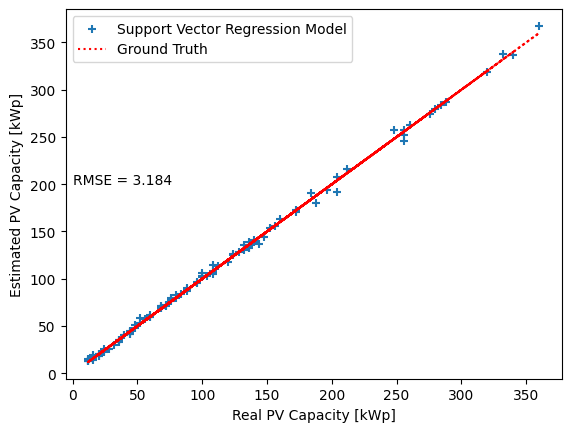

Predicting with Method B...


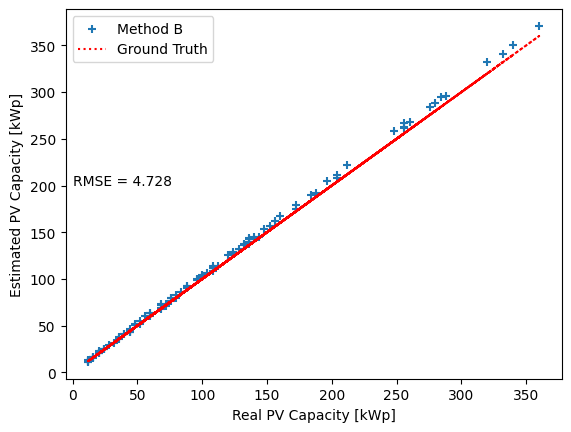

Predicting with Method INM (POA)...


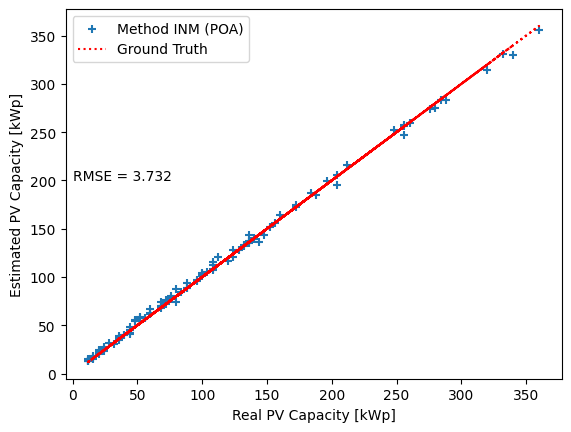

In [11]:
predict_and_plot(X_Test_normalized, y_Test, models, methods)

Generate new substation data with specified parameters

100%|██████████| 1/1 [00:02<00:00,  2.30s/it]


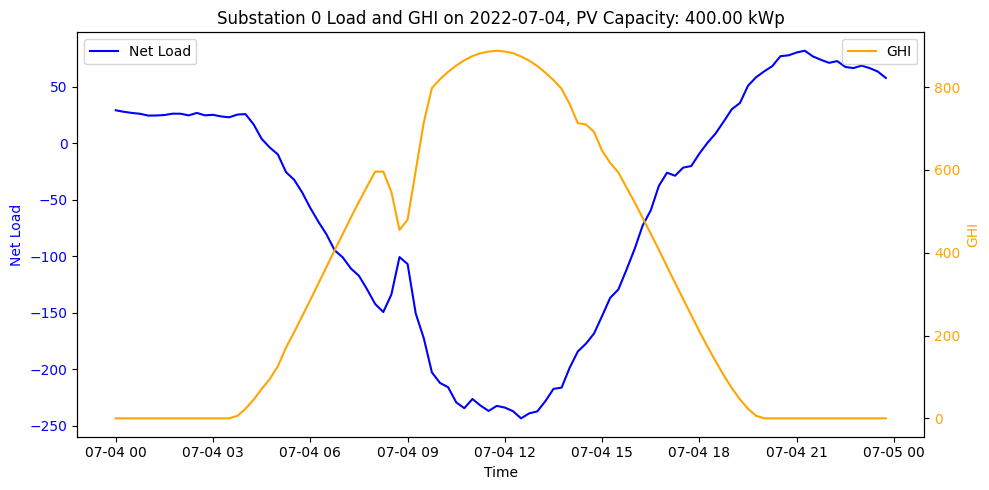

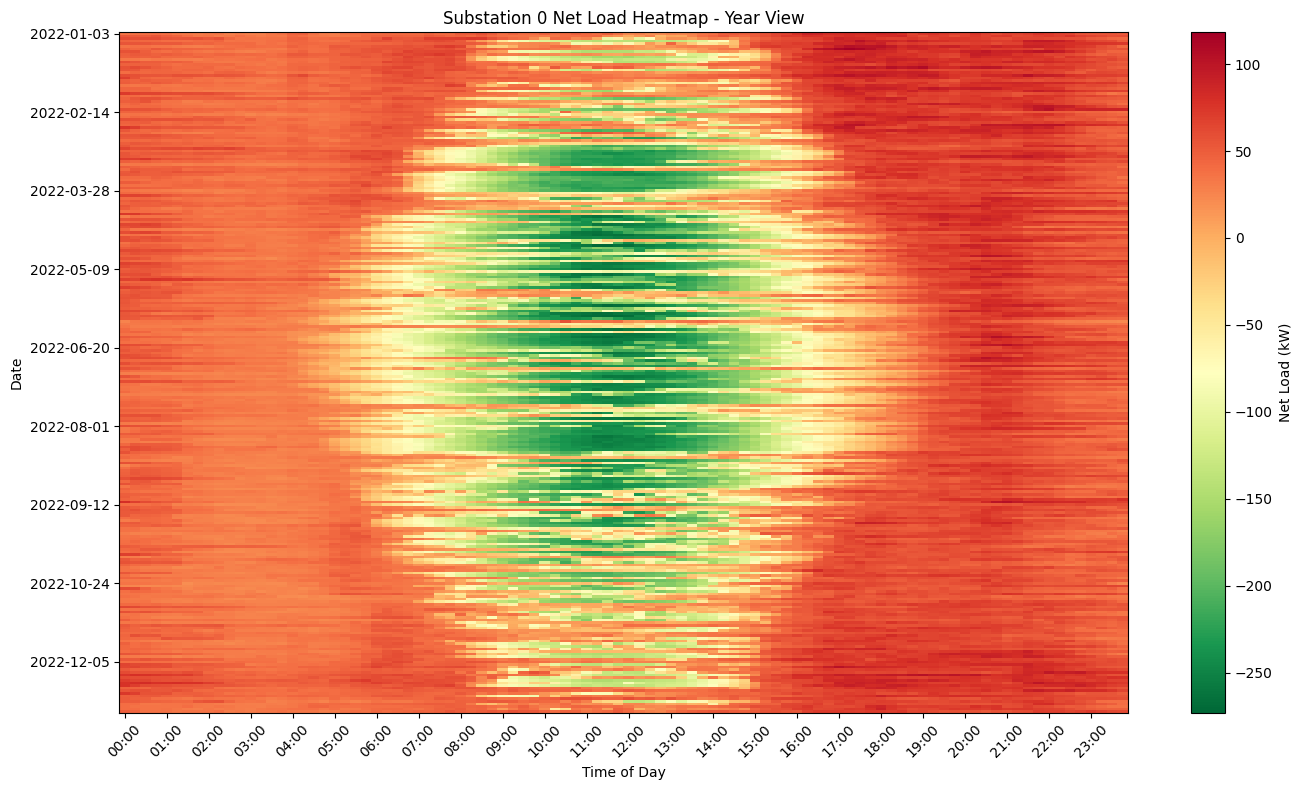

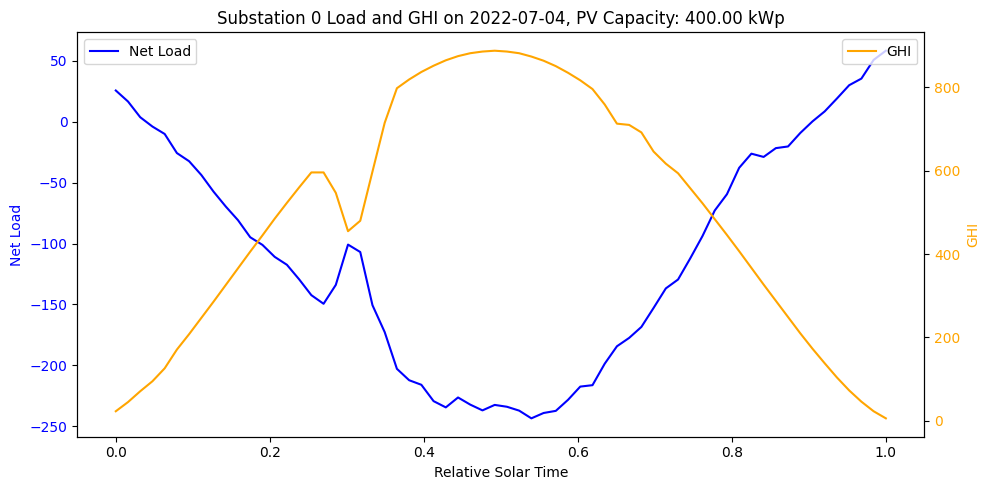

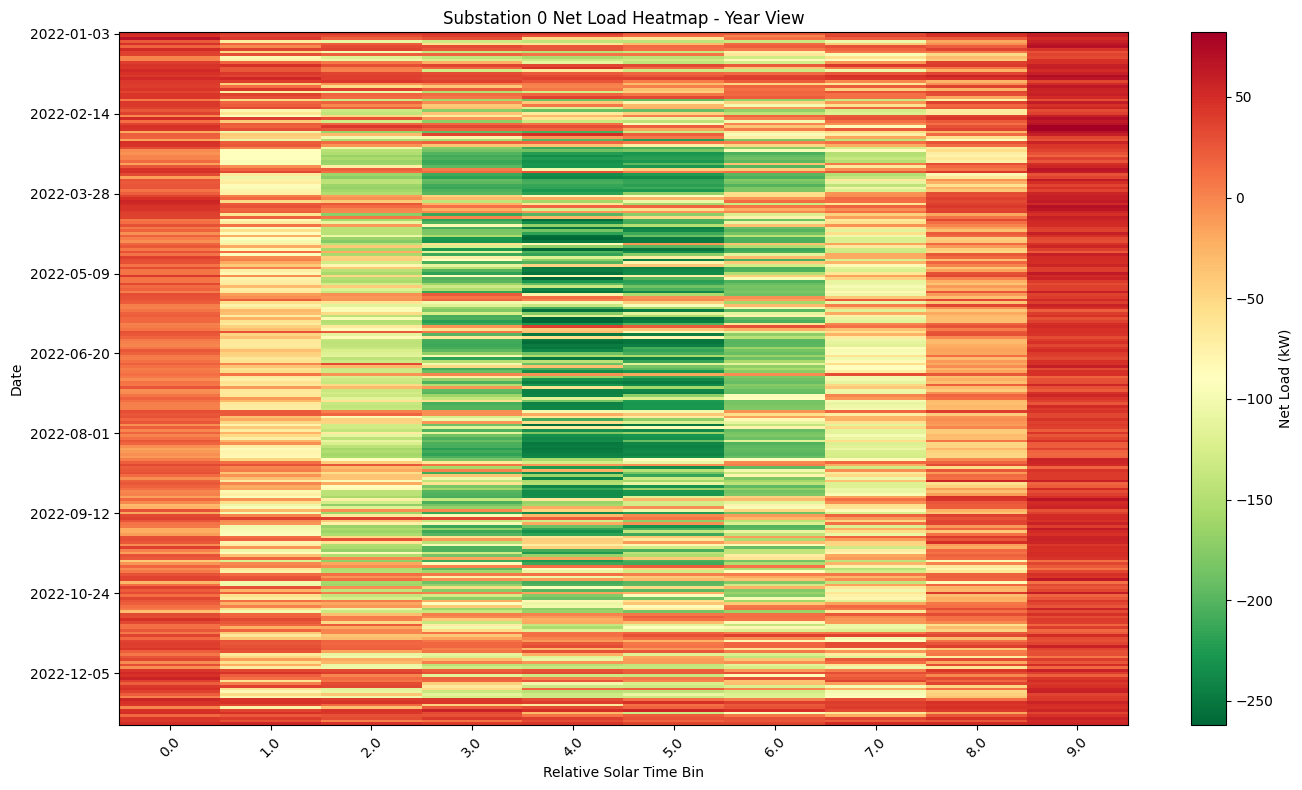

In [21]:
subdata_new, sizes_new, dfs_new, Is_new = createSubstationData(size=100, Pen=1)  # Create new substation data with specified parameters (size: Number of consumers; Pen: PV penetration rate [0-1])
                                                                                 # Other arguments: n (default=1) number of substations to generate, Power (default=4) installed capacity of each panel 
visualizeSubstationLoad(dfs_new, date='2022-07-04')                              
visualizeSubstationLoadSolarTime(dfs_new, date='2022-07-04')

Extract features and labels for new substation

In [22]:
X_new = subdata_new.drop(columns=['maxPV', 'baseline'])
X_new_normalized = scaler.transform(X_new)
y_new = subdata_new['maxPV']

Make estimations for installed PV capacity for the new substation

In [23]:
for model_name, model in models.items():
    if model_name == 'Feedforward Neural Network':
        y_new_pred = model.predict(X_new_normalized, verbose=0)
    else:
        y_new_pred = model.predict(X_new_normalized)
    rmse = root_mean_squared_error(y_new, y_new_pred)
    mape = mean_absolute_percentage_error(y_new, y_new_pred) * 100
    print(f"{model_name}: {y_new_pred.flatten()[0]:.2f} kWp (RMSE: {rmse:.2f} kWp, MAPE: {mape:.2f}%)")

methods_new = modelBasedPrections(dfs_new, Is_new, load_estimation=False)

for method_name, method_pred in methods_new.items():
    rmse = root_mean_squared_error(y_new, method_pred)
    mape = mean_absolute_percentage_error(y_new, method_pred) * 100
    print(f"{method_name}: {method_pred[0]:.2f} kWp (RMSE: {rmse:.2f} kWp, MAPE: {mape:.2f}%)")

Support Vector Regression: 400.66 kWp (RMSE: 0.66 kWp, MAPE: 0.16%)
Method B: 418.10 kWp (RMSE: 18.10 kWp, MAPE: 4.53%)
Method INM (POA): 394.48 kWp (RMSE: 5.52 kWp, MAPE: 1.38%)


## Sensitivity Analysis

Using the function `createSubstationData()`, create different substations with different degrees of PV penetration rates (`Pen`) and number of consumers (`size`). You can use parameter `n` to generate n number of substations to obtain more stable and significant results. However, be wary of computation time, which scales with `n`

Estimate the installed PV capacity using the methods provided. You can choose different methods besides the default ones, but this is not mandatory.

## Generalisation

We now test the methods on different, real datasets. We will use smart meter data with real PV generation and installed capacity values from Austin, Texas (Pecan Street) and from New South Wales, Australia (AusGrid)

### Pecan Street

We start by loading the Austin - Pecan Street dataset

In [24]:
tx_df, tx_features, tx_Is, tx_real_value = loadTexasData()

c:\Users\VENANCIA\KU Leuven\Md Umar Hashmi - ATHENS_course_content\Lab_PV_estimation_kWp\backend.py:1394: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataids.pv.fillna(0, inplace=True)
c:\Users\VENANCIA\KU Leuven\Md Umar Hashmi - ATHENS_course_content\Lab_PV_estimation_kWp\backend.py:1395: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('f

We can inspect the data using the same visualization as before. Anything in particular that stands out?

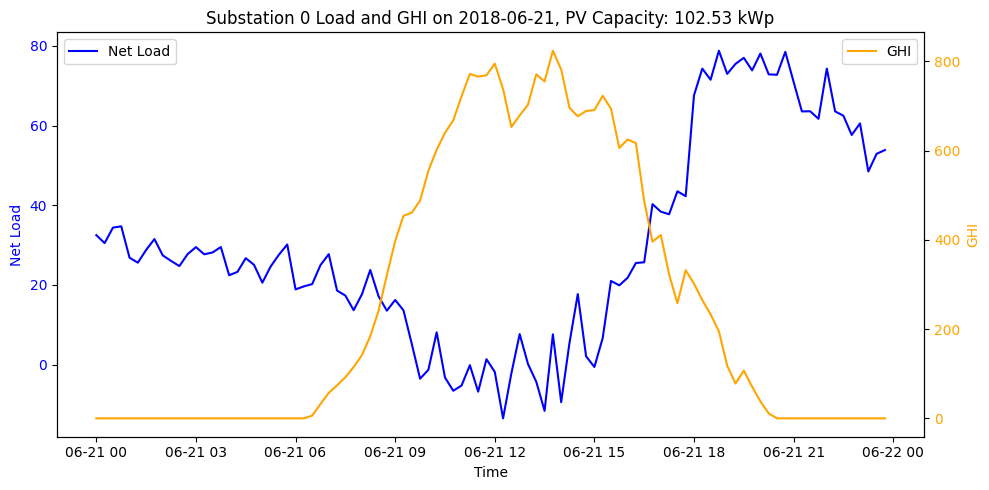

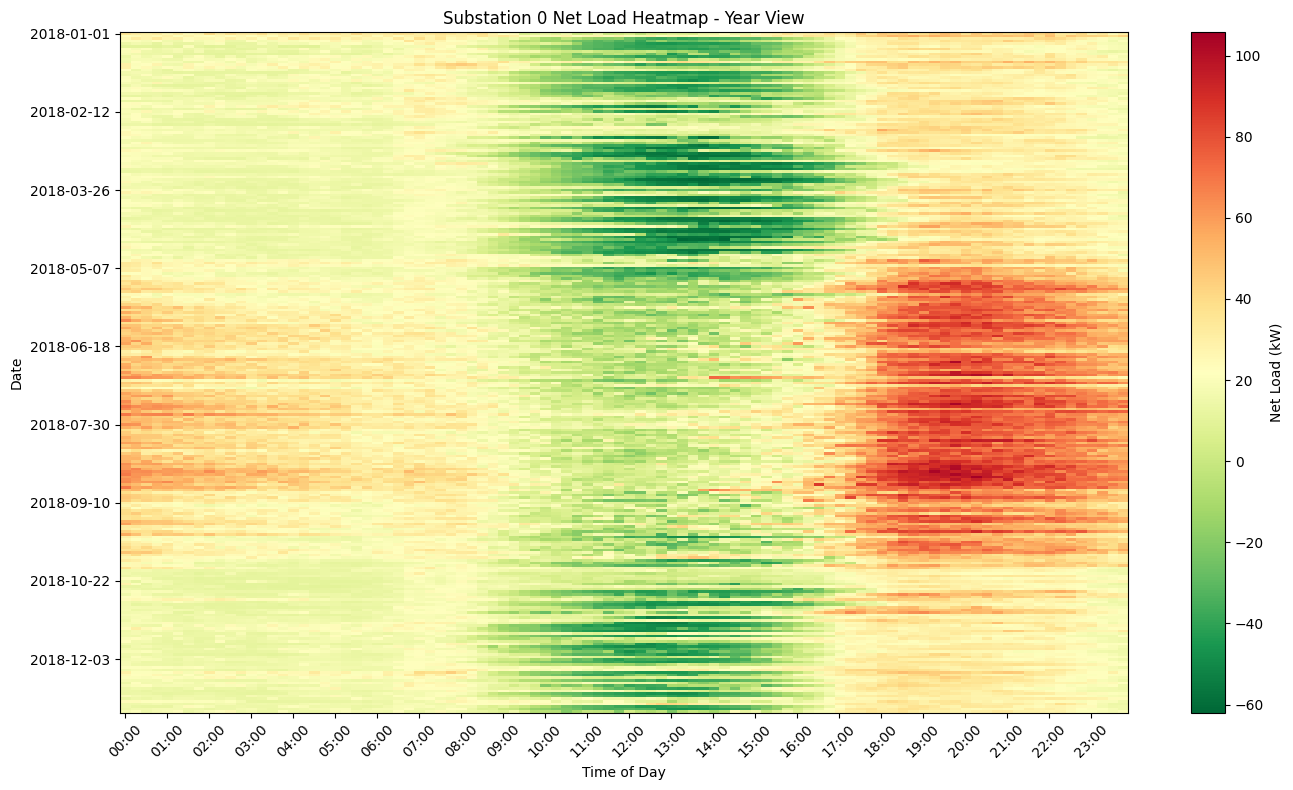

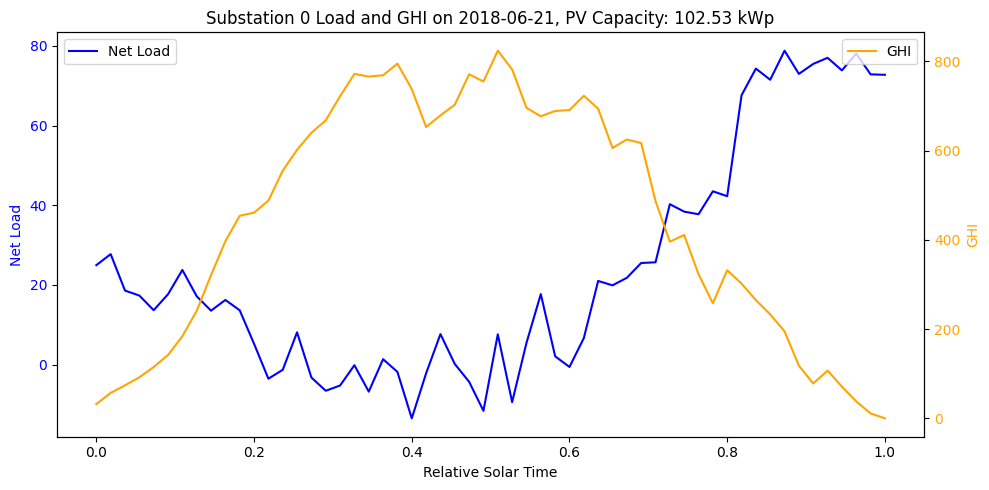

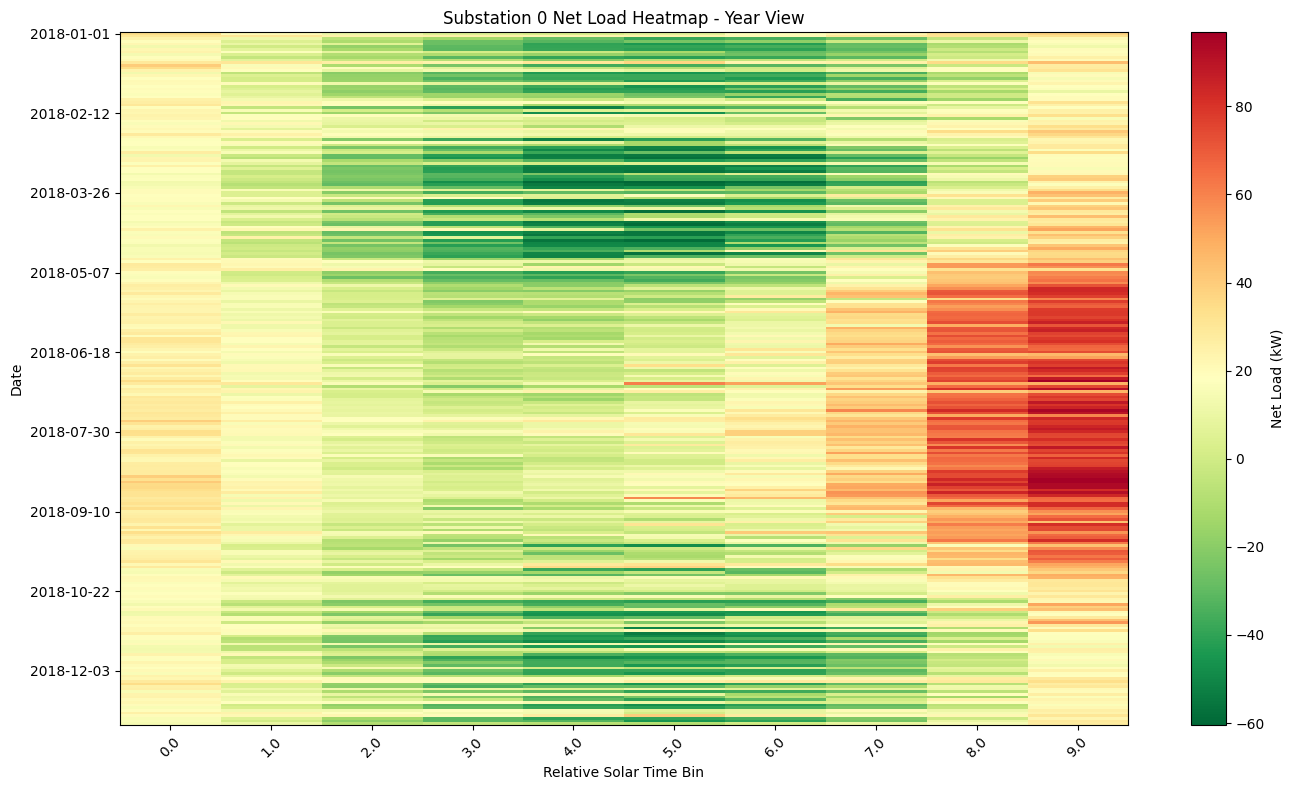

In [25]:
visualizeSubstationLoad(tx_df, date='2018-06-21')                              
visualizeSubstationLoadSolarTime(tx_df, date='2018-06-21')

Test the methods' performance for this data. Which one performs the best?

In [26]:
X = tx_features
y = tx_real_value

# ....

### AusGrid

Here we load data from the AusGrid dataset. Specifically we read the smart meter load profiles and aggregate them by postcode. Here we will only use the 3 postcodes with the most connected consumers. The function `loadAusGridData()` gives us time series, features, POA irradiances and real installed capacity values in dictionaries, which are indexed by postcode ([2259, 2261, 2290])

In [27]:
aus_dfs, aus_features, aus_Is, aus_real_values = loadAusGridData()
aus_dfs.keys()

c:\Users\VENANCIA\KU Leuven\Md Umar Hashmi - ATHENS_course_content\Lab_PV_estimation_kWp\backend.py:1276: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  aus_index = pd.date_range(raw_data_aus.date.min(), raw_data_aus.date.max() + pd.Timedelta(days=1), freq='30T', tz='Australia/Sydney')
c:\Users\VENANCIA\KU Leuven\Md Umar Hashmi - ATHENS_course_content\Lab_PV_estimation_kWp\backend.py:1331: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  weather_data.index = weather_data.index.shift(periods=-1, freq='30T')
c:\Users\VENANCIA\KU Leuven\Md Umar Hashmi - ATHENS_course_content\Lab_PV_estimation_kWp\backend.py:1331: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  weather_data.index = weather_data.index.shift(periods=-1, freq='30T')
c:\Users\VENANCIA\KU Leuven\Md Umar Hashmi - ATHENS_course_content\Lab_PV_estimation_kWp\backend.py:13

dict_keys([2259, 2261, 2290])

We can visualize the load for one of the postcodes

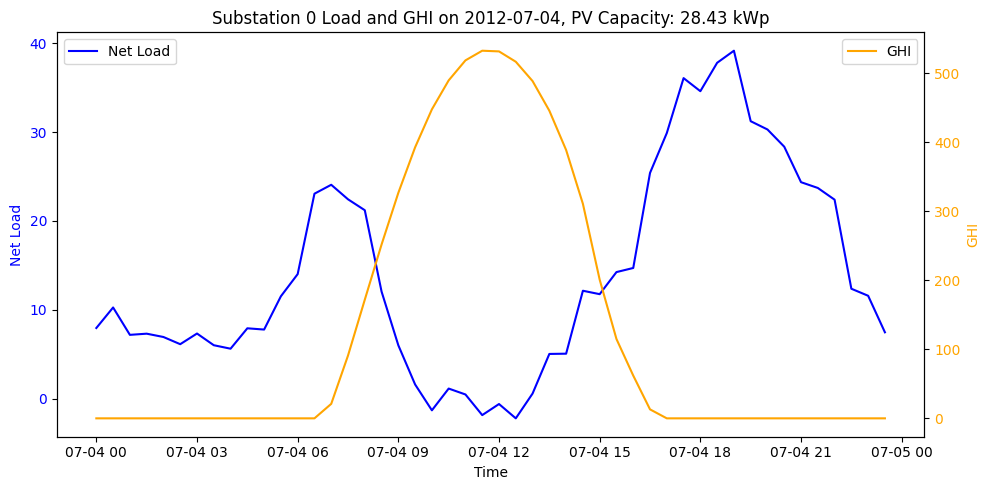

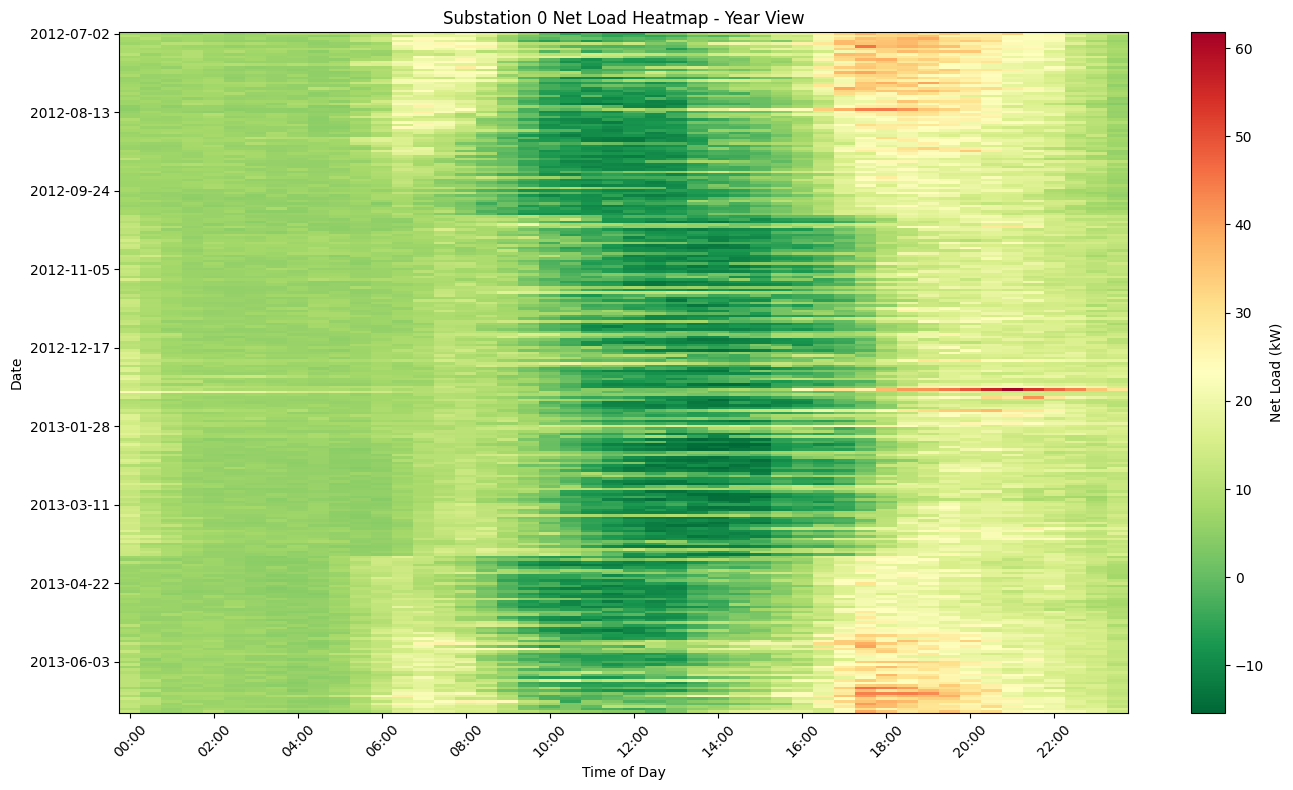

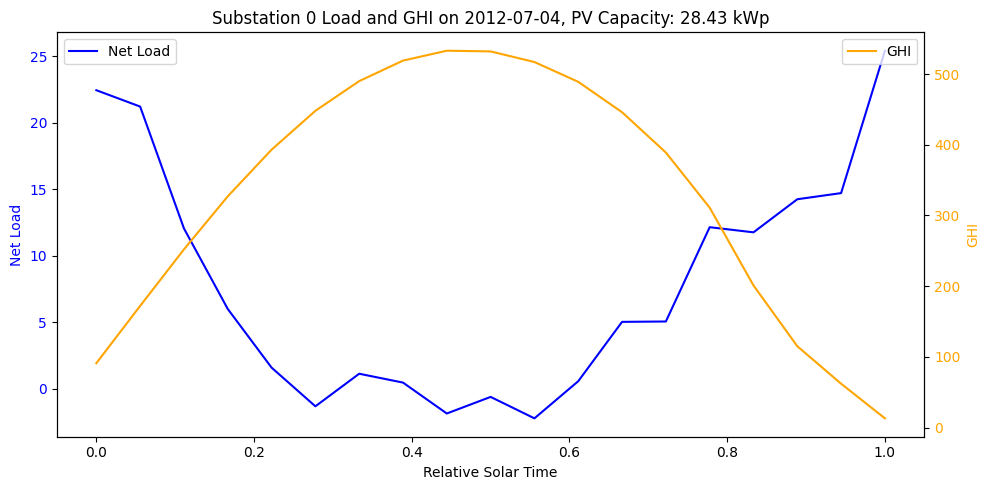

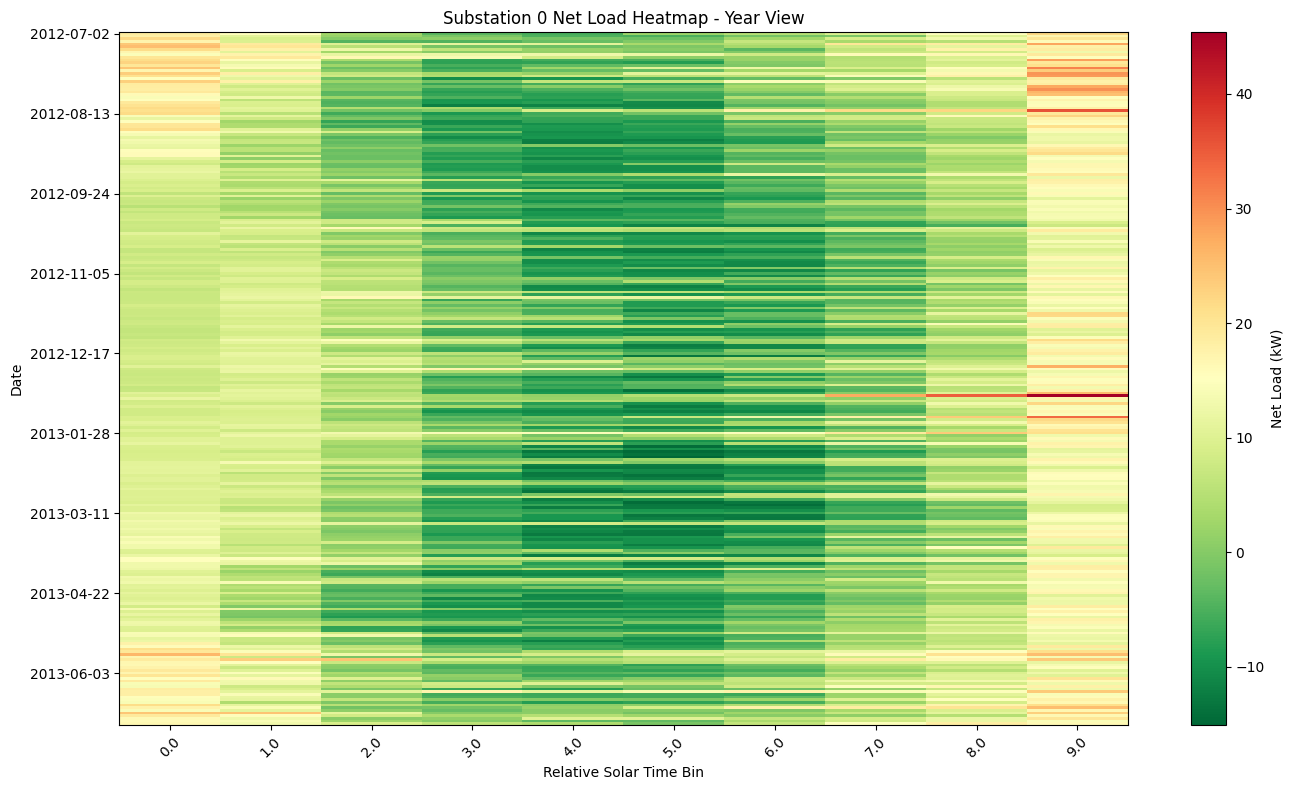

In [28]:
visualizeSubstationLoad(aus_dfs[2261], date='2012-07-04')                              
visualizeSubstationLoadSolarTime(aus_dfs[2261], date='2012-07-04')

Test the methods' performances for each postcode

In [29]:
Postcodes = aus_dfs.keys()

for postcode in Postcodes:
    print(f"Postcode: {postcode}")
    X = aus_features[postcode]
    y = aus_real_values[postcode]
    # ...

Postcode: 2259
Postcode: 2261
Postcode: 2290
